# Task 2: Multi-Modal Cardiac Image Fusion
**Medical Imaging Portfolio** | Author: **23k0069**

### Scenario
Diagnosing cardiac disease requires simultaneous evaluation of hard anatomical boundaries (captured by CT) and subtle myocardial soft-tissue variations (captured by MRI).
This pipeline performs multi-modal matrix fusion: normalizing dynamic ranges, mapping distinct pseudocolor spectra, applying weighted blending ($lpha > eta$), and safeguarding against saturation using logarithmic and gamma curves.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'gray'
print('Fusion environment initialized.')

Fusion environment initialized.


## 1. Load Modalities
Load aligned cross-sectional slices: CT (`data/ct_slice.png`) and MRI (`data/mri_slice.png`).

CT Matrix: (256, 256) | MRI Matrix: (256, 256)


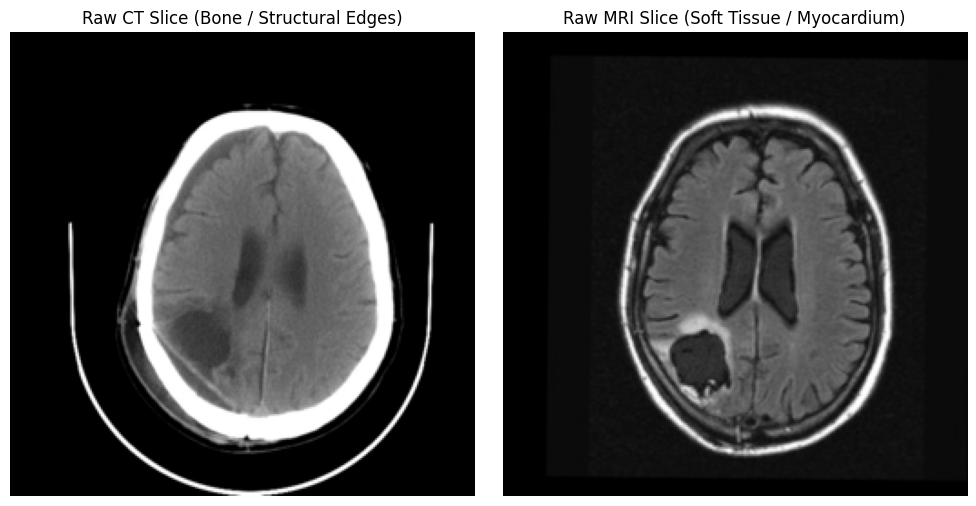

In [2]:
ct = cv2.imread('data/ct_slice.png', cv2.IMREAD_GRAYSCALE)
mri = cv2.imread('data/mri_slice.png', cv2.IMREAD_GRAYSCALE)
print(f'CT Matrix: {ct.shape} | MRI Matrix: {mri.shape}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(ct, cmap='gray')
axes[0].set_title('Raw CT Slice (Bone / Structural Edges)')
axes[0].axis('off')

axes[1].imshow(mri, cmap='gray')
axes[1].set_title('Raw MRI Slice (Soft Tissue / Myocardium)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/01_raw_modalities.png', bbox_inches='tight')
plt.show()

## 2. Independent Histogram Equalization
Equalize each modality separately to maximize individual dynamic range prior to combination.

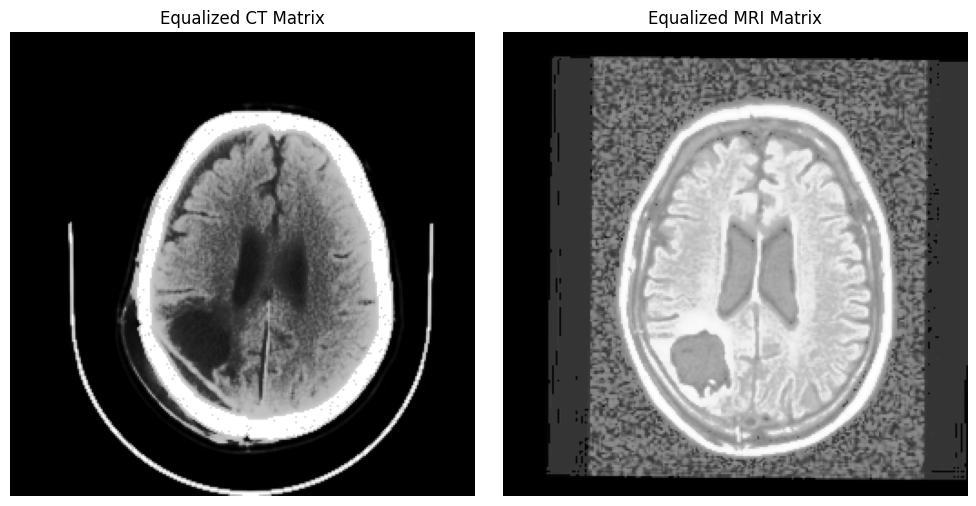

In [3]:
ct_eq = cv2.equalizeHist(ct)
mri_eq = cv2.equalizeHist(mri)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(ct_eq, cmap='gray')
axes[0].set_title('Equalized CT Matrix')
axes[0].axis('off')

axes[1].imshow(mri_eq, cmap='gray')
axes[1].set_title('Equalized MRI Matrix')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/02_equalized_modalities.png', bbox_inches='tight')
plt.show()

## 3. Color Mapping and Visual Differentiation
Convert CT to `COLORMAP_BONE` (sharp anatomical boundaries) and MRI to `COLORMAP_JET` (subtle myocardial gradient transitions).

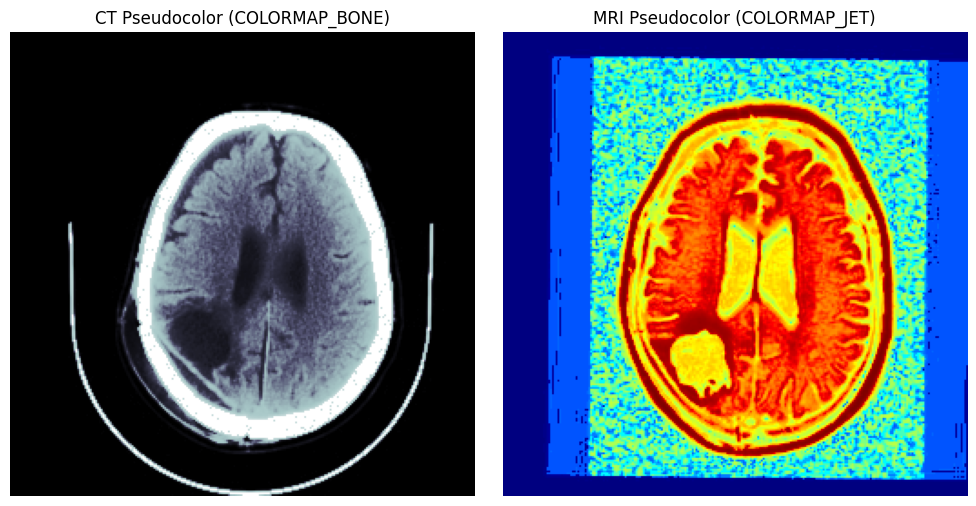

In [4]:
ct_col = cv2.applyColorMap(ct_eq, cv2.COLORMAP_BONE)
mri_col = cv2.applyColorMap(mri_eq, cv2.COLORMAP_JET)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(ct_col, cv2.COLOR_BGR2RGB))
axes[0].set_title('CT Pseudocolor (COLORMAP_BONE)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(mri_col, cv2.COLOR_BGR2RGB))
axes[1].set_title('MRI Pseudocolor (COLORMAP_JET)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/03_modality_colormaps.png', bbox_inches='tight')
plt.show()

## 4. Multi-Modal Weighted Fusion
Blend matrices via linear weighted superposition using `cv2.addWeighted()`:
$$\text{Fused} = \alpha \cdot \text{CT} + \beta \cdot \text{MRI} + 0$$
Assign higher weight to CT ($\alpha = 0.65$) for edge integrity and MRI ($\beta = 0.35$) for soft-tissue variations.

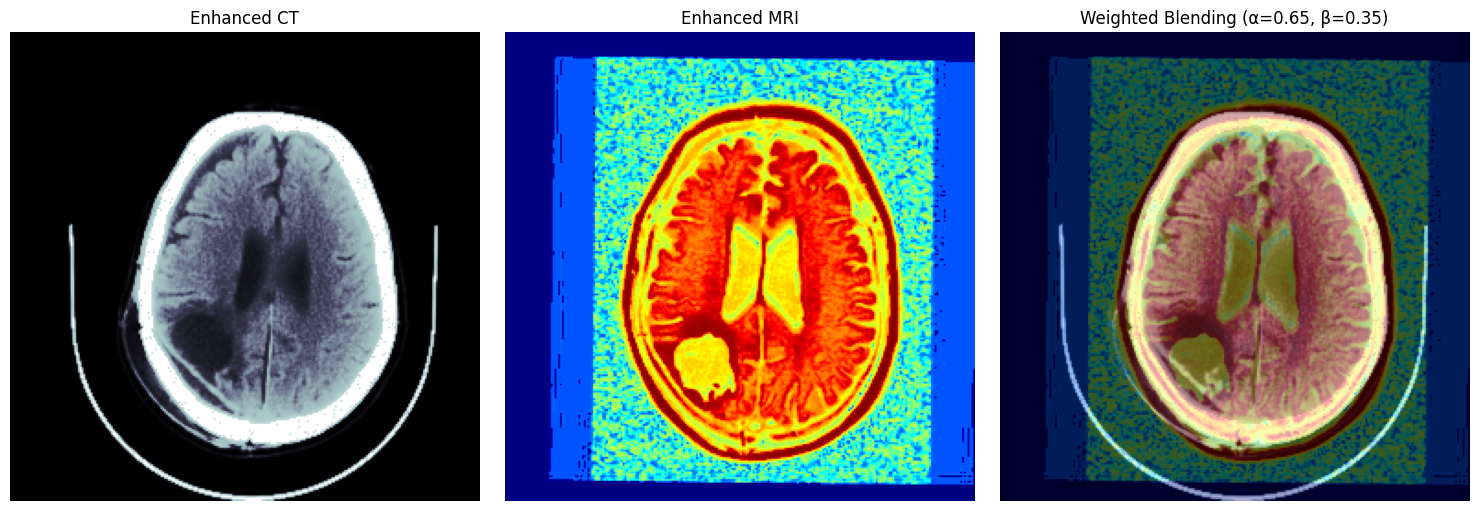

In [5]:
alpha = 0.65
beta = 0.35
fused = cv2.addWeighted(ct_col, alpha, mri_col, beta, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(ct_col, cv2.COLOR_BGR2RGB))
axes[0].set_title('Enhanced CT')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(mri_col, cv2.COLOR_BGR2RGB))
axes[1].set_title('Enhanced MRI')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(fused, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Weighted Blending (α={alpha}, β={beta})')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('output/04_weighted_fusion.png', bbox_inches='tight')
plt.show()

## 5. Logarithmic and Power-Law Dynamic Range Preservation
Safeguard against clipped highlights and crushed shadows resulting from matrix addition through logarithmic re-scaling and gamma tuning ($\gamma = 0.85$).

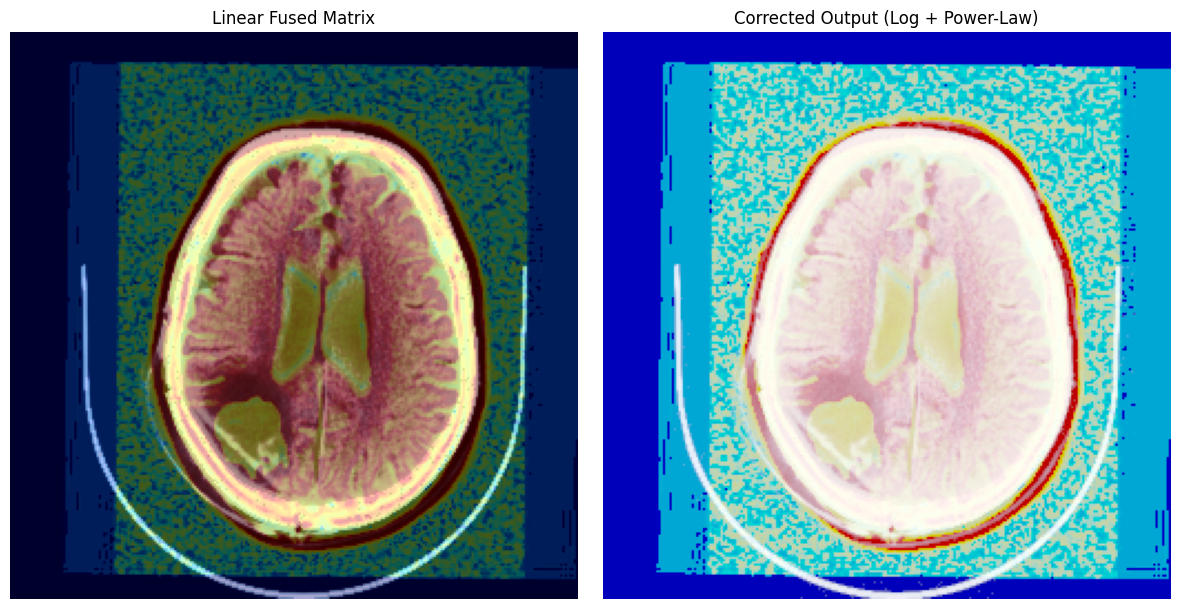

In [6]:
c_log = 255.0 / np.log(1.0 + np.max(fused))
fused_log = (c_log * np.log(1.0 + fused.astype(np.float32))).astype(np.uint8)

gamma = 0.85
fused_final = np.clip(255.0 * ((fused_log / 255.0) ** gamma), 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(fused, cv2.COLOR_BGR2RGB))
axes[0].set_title('Linear Fused Matrix')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(fused_final, cv2.COLOR_BGR2RGB))
axes[1].set_title('Corrected Output (Log + Power-Law)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/05_fused_enhanced.png', bbox_inches='tight')
plt.show()

## 6. Comparative Diagnostic Analysis
Side-by-side comparative inspection validating edge preservation and soft-tissue visibility.

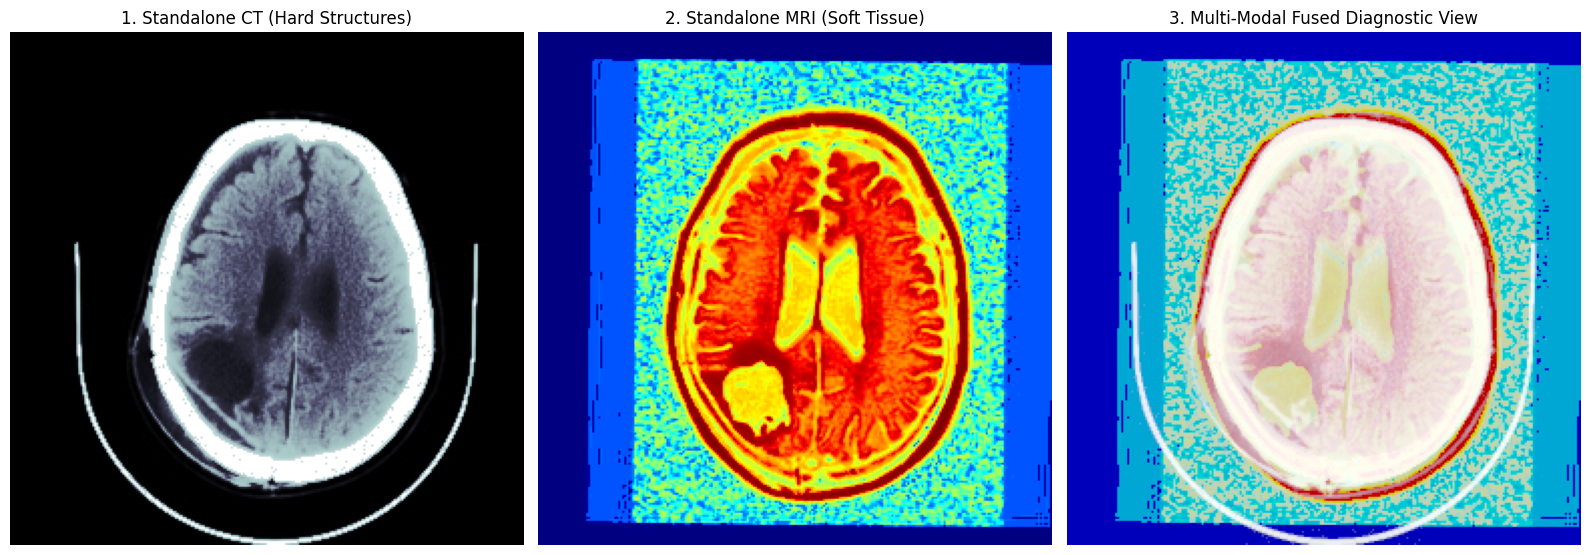

In [7]:
comp = np.hstack([ct_col, mri_col, fused_final])
cv2.imwrite('output/06_comparative_fusion_banner.png', comp)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(ct_col, cv2.COLOR_BGR2RGB))
axes[0].set_title('1. Standalone CT (Hard Structures)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(mri_col, cv2.COLOR_BGR2RGB))
axes[1].set_title('2. Standalone MRI (Soft Tissue)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(fused_final, cv2.COLOR_BGR2RGB))
axes[2].set_title('3. Multi-Modal Fused Diagnostic View')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('output/06_comparative_analysis.png', bbox_inches='tight')
plt.show()